In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
akshit= '\u0905\u0915\u094D\u0937\u093F\u0924'  

print(akshit)



अक्षित


In [3]:
#Data collection 
v=  pd.read_csv("temperatures.csv")

In [4]:
v.head()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC
0,1901,22.40,24.14,29.07,31.91,33.41,33.18,31.21,30.39,30.47,29.97,27.31,24.49,28.96,23.27,31.46,31.27,27.25
1,1902,24.93,26.58,29.77,31.78,33.73,32.91,30.92,30.73,29.80,29.12,26.31,24.04,29.22,25.75,31.76,31.09,26.49
2,1903,23.44,25.03,27.83,31.39,32.91,33.00,31.34,29.98,29.85,29.04,26.08,23.65,28.47,24.24,30.71,30.92,26.26
3,1904,22.50,24.73,28.21,32.02,32.64,32.07,30.36,30.09,30.04,29.20,26.36,23.63,28.49,23.62,30.95,30.66,26.40
4,1905,22.00,22.83,26.68,30.01,33.32,33.25,31.44,30.68,30.12,30.67,27.52,23.82,28.30,22.25,30.00,31.33,26.57


In [5]:
v.tail()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC
112,2013,24.56,26.59,30.62,32.66,34.46,32.44,31.07,30.76,31.04,30.27,27.83,25.37,29.81,25.58,32.58,31.33,27.83
113,2014,23.83,25.97,28.95,32.74,33.77,34.15,31.85,31.32,30.68,30.29,28.05,25.08,29.72,24.90,31.82,32.00,27.81
114,2015,24.58,26.89,29.07,31.87,34.09,32.48,31.88,31.52,31.55,31.04,28.10,25.67,29.90,25.74,31.68,31.87,28.27
115,2016,26.94,29.72,32.62,35.38,35.72,34.03,31.64,31.79,31.66,31.98,30.11,28.01,31.63,28.33,34.57,32.28,30.03
116,2017,26.45,29.46,31.60,34.95,35.84,33.82,31.88,31.72,32.22,32.29,29.60,27.18,31.42,27.95,34.13,32.41,29.69


In [6]:
v.describe()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC
count,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000
mean,1959.000000,23.687436,25.597863,29.085983,31.975812,33.565299,32.774274,31.035897,30.507692,30.486752,29.766581,27.285470,24.608291,29.181368,24.629573,31.517607,31.198205,27.208120
std,33.919021,0.834588,1.150757,1.068451,0.889478,0.724905,0.633132,0.468818,0.476312,0.544295,0.705492,0.714518,0.782644,0.555555,0.911239,0.740585,0.420508,0.672003
min,1901.000000,22.000000,22.830000,26.680000,30.010000,31.930000,31.100000,29.760000,29.310000,29.070000,27.900000,25.700000,23.020000,28.110000,22.250000,29.920000,30.240000,25.740000
25%,1930.000000,23.100000,24.780000,28.370000,31.460000,33.110000,32.340000,30.740000,30.180000,30.120000,29.380000,26.790000,24.040000,28.760000,24.110000,31.040000,30.920000,26.700000
50%,1959.000000,23.680000,25.480000,29.040000,31.950000,33.510000,32.730000,31.000000,30.540000,30.520000,29.780000,27.300000,24.660000,29.090000,24.530000,31.470000,31.190000,27.210000
75%,1988.000000,24.180000,26.310000,29.610000,32.420000,34.030000,33.180000,31.330000,30.760000,30.810000,30.170000,27.720000,25.110000,29.470000,25.150000,31.890000,31.400000,27.610000
max,2017.000000,26.940000,29.720000,32.620000,35.380000,35.840000,34.480000,32.760000,31.840000,32.220000,32.290000,30.110000,28.010000,31.630000,28.330000,34.570000,32.410000,30.030000


In [7]:
v.info


<bound method DataFrame.info of      YEAR    JAN    FEB    MAR    APR    MAY    JUN    JUL    AUG    SEP  \
0    1901  22.40  24.14  29.07  31.91  33.41  33.18  31.21  30.39  30.47   
1    1902  24.93  26.58  29.77  31.78  33.73  32.91  30.92  30.73  29.80   
2    1903  23.44  25.03  27.83  31.39  32.91  33.00  31.34  29.98  29.85   
3    1904  22.50  24.73  28.21  32.02  32.64  32.07  30.36  30.09  30.04   
4    1905  22.00  22.83  26.68  30.01  33.32  33.25  31.44  30.68  30.12   
..    ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
112  2013  24.56  26.59  30.62  32.66  34.46  32.44  31.07  30.76  31.04   
113  2014  23.83  25.97  28.95  32.74  33.77  34.15  31.85  31.32  30.68   
114  2015  24.58  26.89  29.07  31.87  34.09  32.48  31.88  31.52  31.55   
115  2016  26.94  29.72  32.62  35.38  35.72  34.03  31.64  31.79  31.66   
116  2017  26.45  29.46  31.60  34.95  35.84  33.82  31.88  31.72  32.22   

       OCT    NOV    DEC  ANNUAL  JAN-FEB  MAR-MAY  JUN

In [8]:
v.corr()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC
YEAR,1.000000,0.575499,0.647066,0.553886,0.540662,0.407648,0.371840,0.478512,0.654138,0.664008,0.589073,0.697887,0.732222,0.801129,0.679869,0.640438,0.677061,0.749792
JAN,0.575499,1.000000,0.647017,0.457081,0.594674,0.365236,0.292855,0.339337,0.459944,0.499764,0.480695,0.526615,0.595902,0.749880,0.874226,0.575734,0.496515,0.607752
FEB,0.647066,0.647017,1.000000,0.589088,0.548803,0.377722,0.341302,0.418956,0.503188,0.472755,0.466916,0.519595,0.619320,0.792541,0.928731,0.635904,0.544527,0.609839
MAR,0.553886,0.457081,0.589088,1.000000,0.618621,0.387756,0.228349,0.232647,0.382344,0.370066,0.312226,0.498202,0.523316,0.689205,0.584612,0.848637,0.380640,0.505879
APR,0.540662,0.594674,0.548803,0.618621,1.000000,0.563317,0.299866,0.286052,0.490668,0.437970,0.473873,0.538037,0.579775,0.770596,0.643942,0.878402,0.474542,0.596943
MAY,0.407648,0.365236,0.377722,0.387756,0.563317,1.000000,0.274521,0.299072,0.473171,0.347289,0.468993,0.482822,0.444695,0.609015,0.403316,0.708221,0.431314,0.503445
JUN,0.371840,0.292855,0.341302,0.228349,0.299866,0.274521,1.000000,0.480925,0.504354,0.305761,0.380782,0.419968,0.366242,0.520189,0.351115,0.341301,0.749132,0.409325
JUL,0.478512,0.339337,0.418956,0.232647,0.286052,0.299072,0.480925,1.000000,0.622985,0.531865,0.568341,0.535413,0.440813,0.588454,0.423876,0.321388,0.799602,0.541023
AUG,0.654138,0.459944,0.503188,0.382344,0.490668,0.473171,0.504354,0.622985,1.000000,0.680212,0.661177,0.588961,0.595330,0.755384,0.534818,0.560118,0.866202,0.665040
SEP,0.664008,0.499764,0.472755,0.370066,0.437970,0.347289,0.305761,0.531865,0.680212,1.000000,0.680744,0.683866,0.629223,0.730756,0.529533,0.485397,0.778875,0.734650


In [9]:
monthly_columns = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
monthly_data = v[monthly_columns]

In [10]:
# Standardizing the data before applying PCA
scaler = StandardScaler()
monthly_data_scaled = scaler.fit_transform(monthly_data)

# Applying PCA
pca = PCA(n_components=1)
monthly_pca = pca.fit_transform(monthly_data_scaled)

# Adding the PCA result as a new column to the original dataframe
v['MONTHLY_PCA'] = monthly_pca

In [11]:
v.corr()["MONTHLY_PCA"].sort_values(ascending=False)

MONTHLY_PCA    1.000000
ANNUAL         0.988512
OCT-DEC        0.917755
JUN-SEP        0.859390
NOV            0.851729
DEC            0.848124
OCT            0.812615
MAR-MAY        0.810007
JAN-FEB        0.802486
AUG            0.798449
YEAR           0.796998
SEP            0.772477
FEB            0.743128
APR            0.732701
JAN            0.718147
JUL            0.653251
MAR            0.633258
MAY            0.617345
JUN            0.538081
Name: MONTHLY_PCA, dtype: float64

In [12]:
v[['ANNUAL', 'MONTHLY_PCA']].head()

,ANNUAL,MONTHLY_PCA
0,28.96,-0.689853
1,29.22,-0.428795
2,28.47,-2.710225
3,28.49,-3.380420
4,28.30,-2.093893


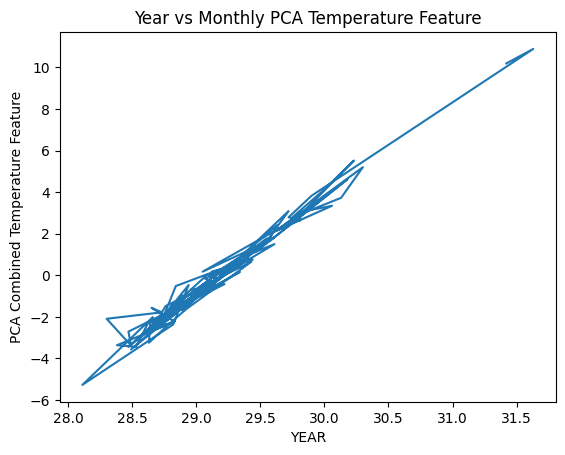

1

In [13]:
plt.plot(v['ANNUAL'], v['MONTHLY_PCA'], label='Monthly PCA'); plt.xlabel("YEAR"); plt.ylabel("PCA Combined Temperature Feature"); plt.title("Year vs Monthly PCA Temperature Feature"); plt.show()
1

In [14]:
x = v[['YEAR']]
y = v[['MONTHLY_PCA']]


In [15]:
train_sse = []
test_sse = []

tr_size = 0.1

while tr_size <= 0.9:
    # Split the data into training and testing sets with varying training sizes
    x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=tr_size, random_state=1)
    
    # Fit the Linear Regression model
    mod = LinearRegression()
    mod.fit(x_train, y_train)
    
    # Predict on the training and testing sets
    pred_train = mod.predict(x_train)
    pred_test = mod.predict(x_test)
    
    # Calculate SSE for training and testing sets
    tr_sse = np.sum((pred_train - y_train)**2, axis=0)
    te_sse = np.sum((pred_test - y_test)**2, axis=0)
    
    # Append the results to the lists
    train_sse.append(tr_sse)
    test_sse.append(te_sse)
    
    # Increase the training size
    tr_size += 0.1


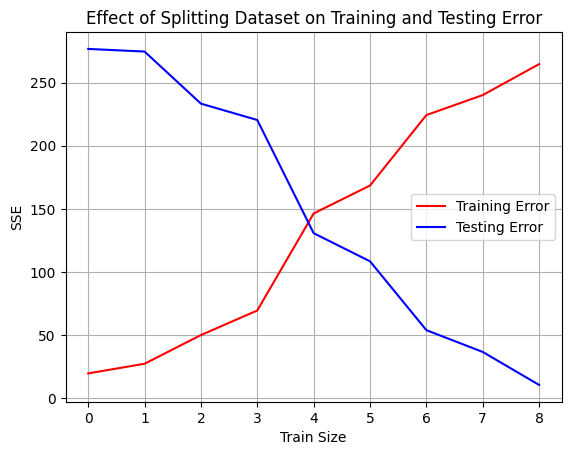

In [16]:


# Plot the SSE against the training size
plt.title("Effect of Splitting Dataset on Training and Testing Error")
plt.plot(np.array(train_sse), c='r')
plt.plot(np.array(test_sse), c='b')
plt.grid(True)
plt.xlabel("Train Size")
plt.ylabel("SSE")

plt.legend(["Training Error", "Testing Error"])
plt.show()

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)


In [18]:
# Check the shapes of the training and testing data
print("x_train.shape:", x_train.shape)
print("x_test.shape:", x_test.shape)
print("y_train.shape:", y_train.shape)
print("y_test.shape:", y_test.shape)

x_train.shape: (93, 1)
x_test.shape: (24, 1)
y_train.shape: (93, 1)
y_test.shape: (24, 1)


In [19]:
# Fit the Linear Regression model
model_h = LinearRegression()
model_h.fit(x_train, y_train)

LinearRegression()

In [20]:
# Predict on the training and testing sets
train_predicted = model_h.predict(x_train)
test_predicted = model_h.predict(x_test)

In [21]:
# Calculate Sum of Squared Errors (SSE) for the training set
train_sse = np.sum((train_predicted - y_train)**2, axis=0)
print("Training SSE:", train_sse)


Training SSE: MONTHLY_PCA    240.058413
dtype: float64


In [22]:
# Calculate Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R²)
mae = round(mean_absolute_error(y_train, train_predicted), 2)
mse = round(mean_squared_error(y_train, train_predicted), 2)
r2 = round(r2_score(y_train, train_predicted), 2)

# Print the results
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R-squared (R²):", r2)

Mean Absolute Error (MAE): 1.12
Mean Squared Error (MSE): 2.58
R-squared (R²): 0.63


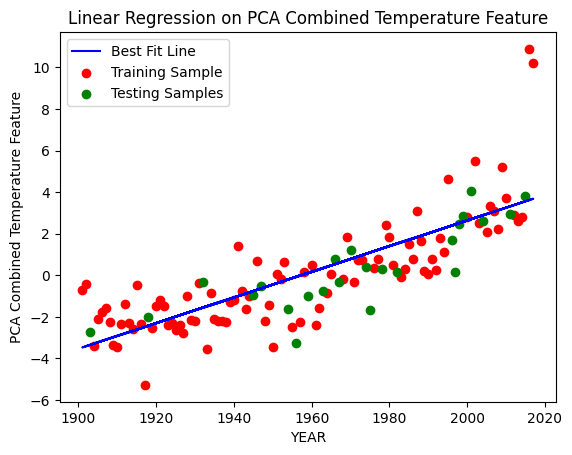

In [23]:
# Plot the results
plt.plot(x_train, train_predicted, c='b')
plt.scatter(x_train, y_train, c='r')
plt.scatter(x_test, y_test, c='g')
plt.legend(["Best Fit Line", "Training Sample", "Testing Samples"])
plt.xlabel("YEAR")
plt.ylabel("PCA Combined Temperature Feature")
plt.title("Linear Regression on PCA Combined Temperature Feature")
plt.show()

In [24]:
v.corr()["MONTHLY_PCA"].sort_values(ascending=False)

MONTHLY_PCA    1.000000
ANNUAL         0.988512
OCT-DEC        0.917755
JUN-SEP        0.859390
NOV            0.851729
DEC            0.848124
OCT            0.812615
MAR-MAY        0.810007
JAN-FEB        0.802486
AUG            0.798449
YEAR           0.796998
SEP            0.772477
FEB            0.743128
APR            0.732701
JAN            0.718147
JUL            0.653251
MAR            0.633258
MAY            0.617345
JUN            0.538081
Name: MONTHLY_PCA, dtype: float64

In [25]:

from mpl_toolkits.mplot3d import Axes3D

In [26]:
features = ['OCT-DEC', 'JUN-SEP', 'NOV']
X = v[features]
y = v['MONTHLY_PCA']

train_sse = []
test_sse = []

In [27]:
train_size = 0.1

In [28]:
while train_size <= 0.9:
    # Splitting the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, random_state=1)
    
    # Training the model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculating SSE
    train_sse.append(np.sum((y_train_pred - y_train) ** 2))
    test_sse.append(np.sum((y_test_pred - y_test) ** 2))
    
    # Increment the train size
    train_size += 0.1

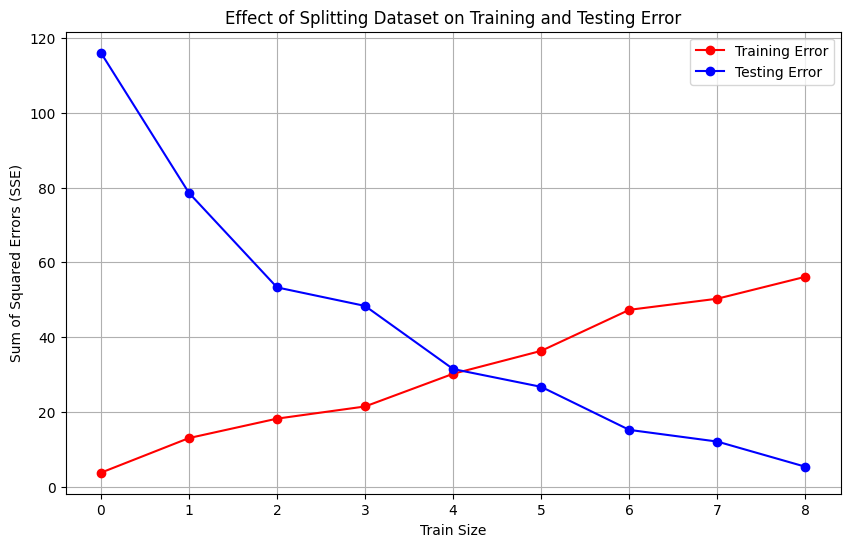

In [29]:
#train_sizes = [i / 10 for i in range(1, 10)]

# Plotting the SSE for training and testing
plt.figure(figsize=(10, 6))
plt.title("Effect of Splitting Dataset on Training and Testing Error")
plt.plot( train_sse, color='red', marker='o')
plt.plot( test_sse, color='blue', marker='o')
plt.grid(True)
plt.xlabel("Train Size")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.legend(["Training Error", "Testing Error"])
plt.show()

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [31]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [32]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [33]:
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

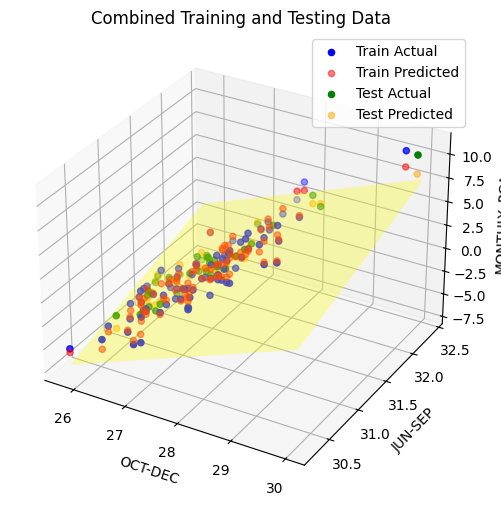

In [34]:
fig = plt.figure(figsize=(12, 6))

# Define the meshgrid for plotting the plane
xx, yy = np.meshgrid(np.linspace(min(X_train['OCT-DEC'].min(), X_test['OCT-DEC'].min()), 
                                 max(X_train['OCT-DEC'].max(), X_test['OCT-DEC'].max()), 50),
                     np.linspace(min(X_train['JUN-SEP'].min(), X_test['JUN-SEP'].min()), 
                                 max(X_train['JUN-SEP'].max(), X_test['JUN-SEP'].max()), 50))

# Calculate the corresponding z values for the plane using the model's coefficients
zz = model.intercept_ + model.coef_[0] * xx + model.coef_[1] * yy

# Combined plot for training and testing data
ax = fig.add_subplot(111, projection='3d')

# Training data
ax.scatter(X_train['OCT-DEC'], X_train['JUN-SEP'], y_train, color='blue', label='Train Actual')
ax.scatter(X_train['OCT-DEC'], X_train['JUN-SEP'], model.predict(X_train), color='red', label='Train Predicted', alpha=0.5)

# Testing data
ax.scatter(X_test['OCT-DEC'], X_test['JUN-SEP'], y_test, color='green', label='Test Actual')
ax.scatter(X_test['OCT-DEC'], X_test['JUN-SEP'], y_test_pred, color='orange', label='Test Predicted', alpha=0.5)

# Plotting the best-fit plane
ax.plot_surface(xx, yy, zz, color='yellow', alpha=0.3, rstride=100, cstride=100)

ax.set_xlabel('OCT-DEC')
ax.set_ylabel('JUN-SEP')
ax.set_zlabel('MONTHLY_PCA')
ax.set_title('Combined Training and Testing Data')
ax.legend()

plt.show()